In [1]:
from pathlib import Path

import prism

from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    GenericMaterials,
    GenericStocks,
    MaterialIntensities,
    RestOf, 
    SharesInflowStocks
)
from imagematerials.preprocessing import get_preprocessing_data

from imagematerials.rest_of import rest_of_preprocessing

from imagematerials.electricity.preprocessing import (
    get_preprocessing_data_gen,
    get_preprocessing_data_grid,
    get_preprocessing_data_stor
)


In [2]:
YEAR_START = 1971  # start year of the simulation period
YEAR_END = 2100    # end year of the calculations
YEAR_OUT = 2100    # year of output generation = last year of reporting

In [3]:
scenario_list = {
    "SSP2_M_CP":("SSP2_M_CP", None)
                 }

    # "SSP2_VLLO":("SSP2_VLLO", None),
    # "SSP2_VLLO_LifeTech":("SSP2_VLLO_LifeTech", ["resource_efficient"]

In [4]:
path_image_scenarios = Path("..", "data", "raw", "image")
scenario_base_path = Path("..", "data", "raw", "circular_economy_scenarios")
path_raw_data = Path("..", "data", "raw")
path_image_materials = Path("..")

In [5]:
model_runs = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    print(f"Running scenario: {scen_id}")
    print(f"Circular economy scenario: {circular_scen}")
    print('Current path: ', Path.cwd())

    # needed for electricity
    scen = climate_scen.split("_")[0]
    variant = "_".join(climate_scen.split("_")[1:])
    
    climate_policy_scenario_dir = path_image_scenarios / climate_scen
    if circular_scen is not None:
        circular_economy_dir = {
            scenario: scenario_base_path / scenario for scenario in circular_scen
        }
    else:
        circular_economy_dir = None

    # Define the complete timeline, including historic tail
    time_start = 1971
    complete_timeline = prism.Timeline(time_start, 2100, 1)
    simulation_timeline = prism.Timeline(1971, 2100, 1)

    # BUILDINGS
    bld_sector = get_preprocessing_data("buildings", path_raw_data, 
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dirs = circular_economy_dir) 
    # VEHICLES
    vhc_sector = get_preprocessing_data("vehicles", path_raw_data, 
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dirs = circular_economy_dir)
    prep_data_vhc = vhc_sector.prep_data
    vhc_sector = Sector('vehicles', prep_data_vhc)

    # GENERATION
    prep_data_gen = get_preprocessing_data_gen(path_image_materials, scen, variant, YEAR_START, YEAR_END, YEAR_OUT)
    sec_electr_gen = Sector("generation", prep_data_gen)
    
    # GRID
    prep_data_lines, prep_data_add = get_preprocessing_data_grid(path_image_materials, scen, variant, YEAR_START, YEAR_END, YEAR_OUT)
    sec_electr_grid_lines = Sector("grid", prep_data_lines)
    sec_electr_grid_add = Sector("grid_additional", prep_data_add)
   
    # STORAGE
    prep_data_phs, prep_data_oth_storage = get_preprocessing_data_stor(path_image_materials, scen, variant, YEAR_START, YEAR_END, YEAR_OUT)
    sec_electr_stor_phs = Sector("storage_pumped_hydropower", prep_data_phs)
    sec_electr_stor_oth = Sector("storage_other", prep_data_oth_storage)

    # REST OF SECTOR
    rest_sector = rest_of_preprocessing(path_raw_data, 
                        image_scenario_directory = climate_policy_scenario_dir, 
                        scenario = climate_scen)
    rest_sector = Sector(name='rest_of', data = rest_sector)
    

    factory = ModelFactory(
    [bld_sector, vhc_sector, sec_electr_gen, rest_sector, 
     sec_electr_grid_lines, sec_electr_grid_add, sec_electr_stor_phs, sec_electr_stor_oth], complete_timeline #
    ).add(GenericStocks, ["buildings", "vehicles", "generation", "grid", "grid_additional", 'storage_pumped_hydropower'] # 
    ).add(GenericMaterials,  "vehicles"
    ).add(SharesInflowStocks, "storage_other"
    ).add(MaterialIntensities, ["buildings", "generation", "grid", 
                                "grid_additional", "storage_pumped_hydropower", "storage_other"] # 
                                
    ).add(RestOf, "rest_of", input_sources={
        "gompertz_coefs": "rest_of",
        "gdp_per_capita": "rest_of",
        "population": "rest_of",
        "historic_diff_consumption_mean": "rest_of",
        "historic_diff_consumption_total": "rest_of"
}
    )
    model = factory.finish()
    model_runs[climate_scen] = model

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)
        model.save_pkl(f'model_results/{scen_id}_model.pkl')



Running scenario: SSP2_M_CP
Circular economy scenario: None
Current path:  c:\Coding\image-materials\examples
Path to image output: ..\data\raw\image\SSP2_M_CP\EnergyServices


c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


grid_stock_lines to xarray Dataset
materials_grid_kgperkm to xarray Dataset
lifetime_grid_distr not in conversion_table
grid_stock_add to xarray Dataset
materials_grid_add_kgperunit to xarray Dataset
lifetime_grid_distr not in conversion_table
Path to image output: ..\data\raw\image\SSP2_M_CP\EnergyServices
phs_stock to xarray Dataset
phs_materials to xarray Dataset
phs_lifetime_distr not in conversion_table
oth_storage_stock to xarray Dataset
oth_storage_lifetime_distr not in conversion_table
oth_storage_shares to xarray Dataset


In [6]:

from imagematerials.rest_of.util import sum_inflows_for_all_sectors


base_run = ModelFactory.load_pkl(f"model_results/SSP2_M_CP_model.pkl")

list_sum_sectors = ["buildings", "vehicles", "generation", "grid"]
list_sum_sectors_all = ["buildings", "vehicles", "generation", "grid", "grid_additional", "storage_pumped_hydropower", "storage_other"]

# # # total_inflow_1 = sum_inflows_for_all_sectors(base_run, 'inflow_materials', list_sum_sectors)
total_inflow = sum_inflows_for_all_sectors(base_run, 'inflow_materials', list_sum_sectors_all)


In [7]:
# save image materials sexctoral sums for rest_of preprocessing
# from imagematerials.rest_of.preprocessing.main import sum_and_save
# total_inflow = sum_and_save(base_run, list_sum_sectors_all, save_path="../data")


In [10]:
base_run.buildings.get('inflow_materials').to_array()

<xarray.DataArray (time: 130, Region: 26, Type: 12, material: 8)> Size: 3MB
<Quantity([[[[4.14570823e+06 1.17517953e+09            nan ... 2.38269055e+07
    4.67120482e+08 1.73746639e+08]
   [2.65955253e+07 7.53900545e+09            nan ... 1.52854237e+08
    2.99666882e+09 1.11461851e+09]
   [6.77727084e+07 3.39012174e+10            nan ... 4.18811762e+08
    5.99896022e+09 6.93244955e+09]
   ...
   [1.09105589e+07 7.69105335e+09 1.75192403e+10 ... 3.87436172e+07
    1.65194768e+09 3.94116106e+08]
   [6.10898507e+06 4.30633578e+09 2.55205968e+09 ... 2.16931306e+07
    9.24950208e+08 2.20671501e+08]
   [5.53703628e+07 3.90315857e+10 3.04988998e+10 ... 1.96621288e+08
    8.38352493e+09 2.00011310e+09]]

  [[1.59892498e+07 4.73219251e+09            nan ... 9.78933662e+07
    1.97909625e+09 6.72201114e+08]
   [1.36122494e+08 4.02869337e+10            nan ... 8.33403025e+08
    1.68487903e+10 5.72270077e+09]
   [9.49745552e+08 4.65908341e+11            nan ... 7.76444310e+09
    8.20421754e+10 9.45262939e+10]
...
   [8.94633622e+07 6.30643672e+10 1.43652599e+11 ... 3.17686225e+08
    1.35454834e+10 3.23163574e+09]
   [3.04461922e+07 2.14620801e+10 1.27190521e+10 ... 1.08115050e+08
    4.60980203e+09 1.09979102e+09]
   [9.20856871e+07 6.49128922e+10 5.07222999e+10 ... 3.26998154e+08
    1.39425248e+10 3.32636054e+09]]

  [[3.25577270e+06 1.06175234e+09            nan ... 1.48455690e+07
    7.27473296e+07 1.36875342e+08]
   [2.85147889e+07 9.29906557e+09            nan ... 1.30020830e+08
    6.37137461e+08 1.19878500e+09]
   [5.35598174e+07 2.96534278e+10            nan ... 3.49938585e+08
    7.97097176e+08 5.47878573e+09]
   ...
   [5.16775184e+07 3.64284319e+10 8.29793296e+10 ... 1.83507923e+08
    7.82439815e+09 1.86671852e+09]
   [1.58039667e+07 1.11405064e+10 6.60218773e+09 ... 5.61202083e+07
    2.39284957e+09 5.70877981e+08]
   [6.70203613e+07 4.72438836e+10 3.69159092e+10 ... 2.37990671e+08
    1.01474298e+10 2.42093958e+09]]]], 'kilogram')>
Coordinates:
  * time      (time) int64 1kB 1971 1972 1973 1974 1975 ... 2097 2098 2099 2100
  * Region    (Region) <U5 520B 'CAN' 'USA' 'MEX' 'RCAM' ... 'OCE' 'RSAS' 'RSAF'
  * Type      (Type) <U21 1kB 'Appartment - Rural' ... 'Govt+'
  * material  (material) <U9 288B 'aluminium' 'brick' ... 'steel' 'wood'

c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_21044\1331293321.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = plt.cm.get_cmap('tab20')(np.linspace(0, 1, 20))
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_21044\1331293321.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20b = plt.cm.get_cmap('tab20b')(np.linspace(0, 1, 20))
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_21044\1331293321.py:22: Mat

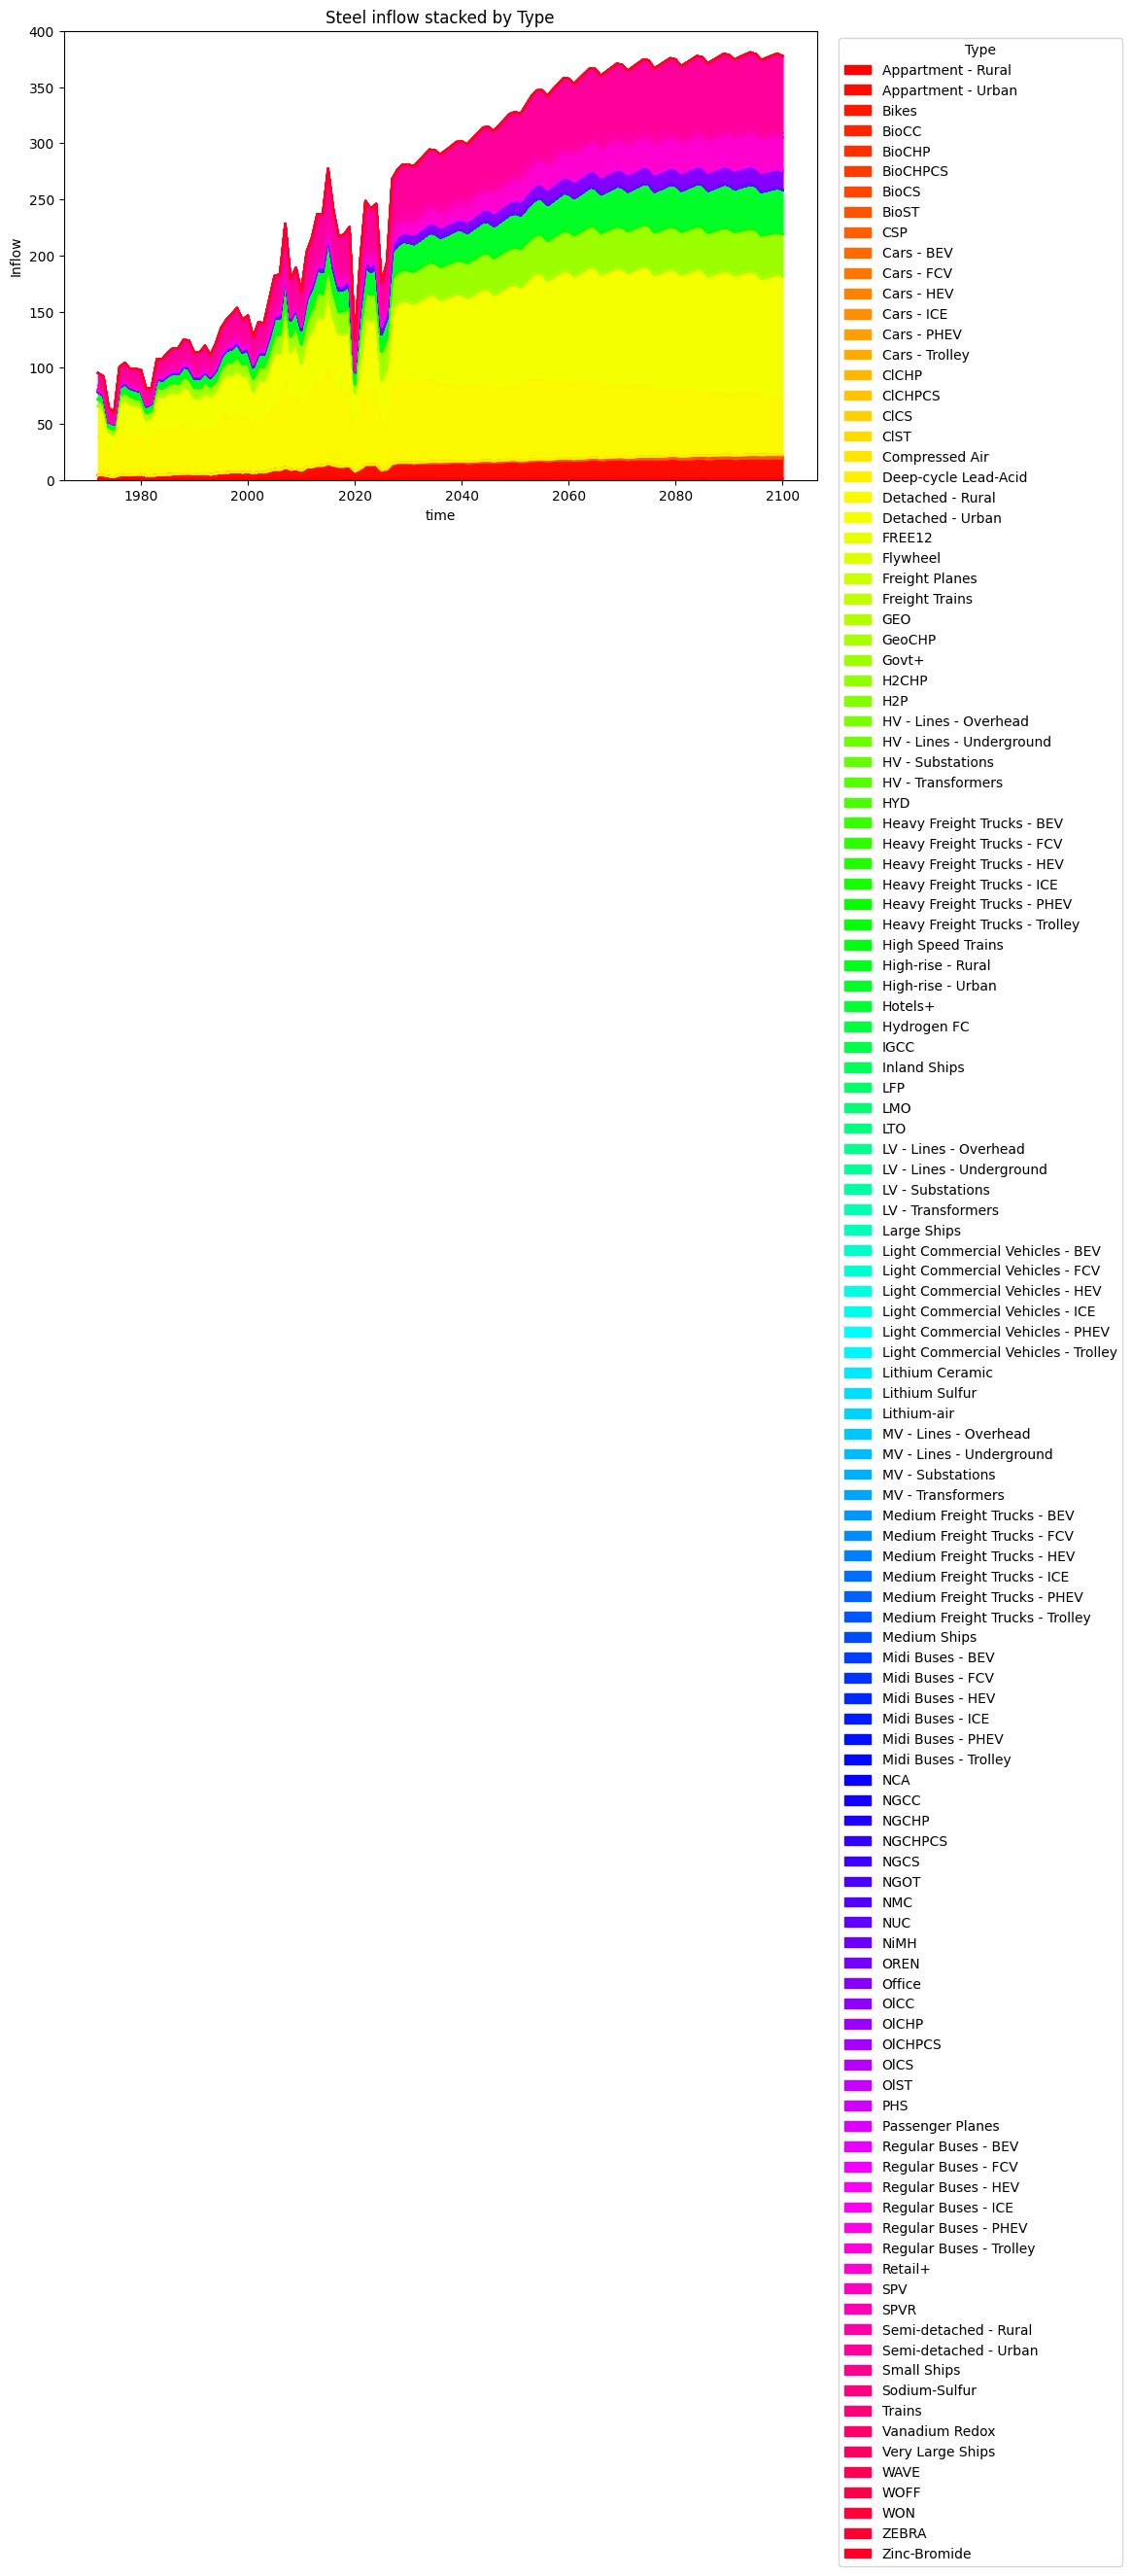

In [8]:
# plot steel inflow stacked by Type (preserves Type dimension) with unique colors
df = total_inflow.sel(material='wood').sum('Region').loc[1972:].fillna(0)

df = df.pint.to('Mt')
df = df.to_pandas()


# ensure predictable column order and string labels
df = df.astype(float)
df.columns = [str(c) for c in df.columns]
df = df.reindex(columns=sorted(df.columns))

import matplotlib.pyplot as plt
import numpy as np

ncols = len(df.columns)

# build a palette: try concatenating tab20 / tab20b / tab20c, else sample a continuous map
try:
    tab20 = plt.cm.get_cmap('tab20')(np.linspace(0, 1, 20))
    tab20b = plt.cm.get_cmap('tab20b')(np.linspace(0, 1, 20))
    tab20c = plt.cm.get_cmap('tab20c')(np.linspace(0, 1, 20))
    base_colors = np.vstack([tab20, tab20b, tab20c])
except Exception:
    # fallback if some maps not available
    base_colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, max(20, ncols)))

if ncols <= base_colors.shape[0]:
    colors = [tuple(c) for c in base_colors[:ncols]]
else:
    # if still not enough, sample a continuous hue map (hsv) for distinct colors
    cmap = plt.cm.get_cmap('hsv')
    colors = [cmap(i / ncols) for i in range(ncols)]

fig, ax = plt.subplots(figsize=(10, 6))
df.plot.area(ax=ax, stacked=True, color=colors)
ax.set_ylabel('Inflow')
ax.set_title('Steel inflow stacked by Type')
ax.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

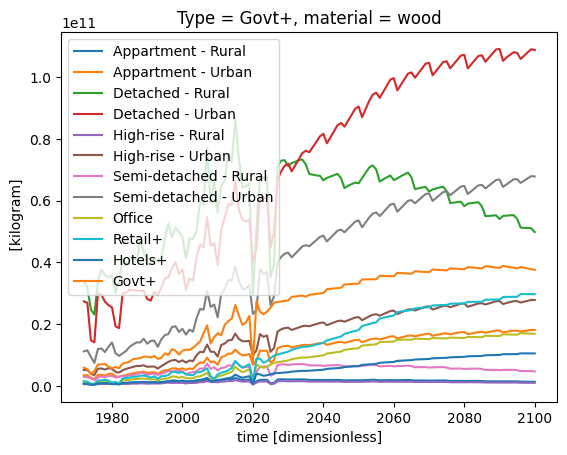

In [9]:
for type in base_run.buildings.get("inflow_materials").to_array().sel(material = "wood").sum("Region").Type.values:
    base_run.buildings.get("inflow_materials").to_array().sel(material = "wood", Type=type).sum("Region").loc[1972:].plot(label = type)

plt.legend()